# 1 Импорт библиотек и функций

## 1.1 Библиотеки

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

## 1.2 Функции

In [152]:
def visualize_predictions_comparison(results_df):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame с колонками ['begin', 'target_price_change', 'predict']
    """
    # Конвертируем дату если нужно
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])
    
    # Сортируем по дате
    results_df = results_df.sort_values('begin')
    
    # Создаем один большой график
    plt.figure(figsize=(16, 8))
    
    # График реальных и предсказанных изменений
    plt.plot(results_df['begin'], results_df['target_price_change'], 
             linewidth=3, color='#2E8B57', label='Реальное изменение', marker='o', markersize=4, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=3, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=4, alpha=0.8)
    
    # Нулевая линия
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    # Настройки графика
    plt.title('Сравнение реальных и предсказанных изменений цены', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Изменение цены (%)', fontsize=14)
    plt.xlabel('Дата', fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Красивое оформление
    plt.tight_layout()
    plt.show()

In [43]:
def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Accuracy направления (важно для торговли)
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")
    
    return {
        'mae': mae,
        'rmse': rmse, 
        'r2': r2,
        'direction_accuracy': direction_accuracy
    }

In [45]:
def train_predict_rf(X_train, X_test, y_train):
    """Обучает и предсказывает Random Forest для регрессии"""
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    model = RandomForestRegressor(random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Random Forest - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

def train_predict_dt(X_train, X_test, y_train):
    """Обучает и предсказывает Decision Tree для регрессии"""
    param_grid = {
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['squared_error', 'friedman_mse']
    }
    
    model = DecisionTreeRegressor(random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Decision Tree - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

def train_predict_linear_reg(X_train, X_test, y_train):
    """Обучает и предсказывает Linear Regression с нормализацией"""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    param_grid = {
        'fit_intercept': [True, False]
    }
    
    model = LinearRegression()
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"Linear Regression - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test_scaled)
    return y_pred

def train_predict_catboost(X_train, X_test, y_train):
    """Обучает и предсказывает CatBoost для регрессии"""
    param_grid = {
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5],
        'iterations': [100, 200, 500]
    }
    
    model = CatBoostRegressor(verbose=False, random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"CatBoost - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

In [47]:
def train_test_split_by_date(df, target_column, test_size=0.2):
    """
    Разбивает данные на train/test по дате и возвращает X, y
    
    Args:
        df: DataFrame с колонкой 'begin'
        target_column: название целевой переменной
        test_size: доля тестовых данных (0.2 = 20%)
    """
    df = df.sort_values('begin').reset_index(drop=True)
    
    # Вычисляем индекс разбиения
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df['begin'].min()} - {train_df['begin'].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df['begin'].min()} - {test_df['begin'].max()} ({len(test_df)} samples)")
    
    # Удаляем колонку 'begin' и разделяем на X, y
    X_train = train_df.drop(columns=['begin', target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=['begin', target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

# 2 Подготовка данных

## 2.0 Список тикеров

In [21]:
tickers = [
    'SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN'
]

## 2.1 Чтение

In [30]:
data_SBER = pd.read_csv("../../data/stock_features_data/stocks_features_SBER.csv")
data_TCSG = pd.read_csv("../../data/stock_features_data/stocks_features_TCSG.csv")
data_GAZP = pd.read_csv("../../data/stock_features_data/stocks_features_GAZP.csv")
data_LKOH = pd.read_csv("../../data/stock_features_data/stocks_features_LKOH.csv")
data_ROSN = pd.read_csv("../../data/stock_features_data/stocks_features_ROSN.csv")
data_ROSN.head(2)

,begin,close,MA_90,RSI_14,RSI_90,MOM_10,ATR_14,VOLATILITY_20,VOLATILITY_50,VOLUME_RATIO_20,MACD_SIGNAL,MACD_HISTOGRAM,target_price_change,target_class
0,2022-05-31 18:00:00,377.00,385.952778,41.700213,46.109636,-6.102117,6.815141,0.177819,0.184228,0.180549,1.622548,-2.115281,-4.721485,L
1,2022-06-01 10:00:00,378.35,385.708333,43.536971,46.522581,-3.703232,6.960488,0.153935,0.177697,0.770980,1.125999,-1.986196,-4.916083,L


## 2.2 Удаление лишних признаков

In [33]:
# Для SBER
part_SBER = data_SBER[['begin', 'close', 'target_class']]
data_SBER.drop(['close', 'target_class'], axis=1, inplace=True)

# Для TCSG
part_TCSG = data_TCSG[['begin', 'close', 'target_class']]
data_TCSG.drop(['close', 'target_class'], axis=1, inplace=True)

# Для GAZP
part_GAZP = data_GAZP[['begin', 'close', 'target_class']]
data_GAZP.drop(['close', 'target_class'], axis=1, inplace=True)

# Для LKOH
part_LKOH = data_LKOH[['begin', 'close', 'target_class']]
data_LKOH.drop(['close', 'target_class'], axis=1, inplace=True)

# Для ROSN
part_ROSN = data_ROSN[['begin', 'close', 'target_class']]
data_ROSN.drop(['close', 'target_class'], axis=1, inplace=True)

## 2.3 Разделение на train/test

In [36]:
X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=data_SBER, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG = train_test_split_by_date(
    df=data_TCSG, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=data_GAZP, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH = train_test_split_by_date(
    df=data_LKOH, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN = train_test_split_by_date(
    df=data_ROSN, 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-05-31 18:00:00 - 2025-04-01 16:00:00 (3642 samples)
Test:  2025-04-01 18:00:00 - 2025-10-15 18:00:00 (911 samples)
Признаков: 10
Train: 2022-05-31 18:00:00 - 2024-06-06 10:00:00 (2472 samples)
Test:  2024-06-06 12:00:00 - 2024-11-27 18:00:00 (618 samples)
Признаков: 10
Train: 2022-05-31 18:00:00 - 2025-04-01 16:00:00 (3642 samples)
Test:  2025-04-01 18:00:00 - 2025-10-15 18:00:00 (911 samples)
Признаков: 10
Train: 2022-05-31 18:00:00 - 2025-04-01 16:00:00 (3642 samples)
Test:  2025-04-01 18:00:00 - 2025-10-15 18:00:00 (911 samples)
Признаков: 10
Train: 2022-05-31 18:00:00 - 2025-04-01 16:00:00 (3642 samples)
Test:  2025-04-01 18:00:00 - 2025-10-15 18:00:00 (911 samples)
Признаков: 10


# 3 Обучение моделей с подбором гиперпараметров

## 3.1 Дерево решений

### 3.1.1 Сбер

In [49]:
y_pred_SBER = train_predict_dt(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

📊 МОДЕЛЬ: 
MAE: 1.2657%
RMSE: 1.9575%
R²: 0.4871
Accuracy направления: 0.8771


{'mae': 1.2656550275539011,
 'rmse': 1.9575135821251652,
 'r2': 0.48708175767497963,
 'direction_accuracy': 0.8770581778265643}

### 3.1.2 Тиньк

In [51]:
y_pred_TCSG = train_predict_dt(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

Decision Tree - лучшие параметры: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

📊 МОДЕЛЬ: 
MAE: 1.8217%
RMSE: 2.3068%
R²: 0.7862
Accuracy направления: 0.8511


{'mae': 1.8216712429964916,
 'rmse': 2.3068305148443726,
 'r2': 0.7862177649337827,
 'direction_accuracy': 0.8511326860841424}

### 3.1.3 Газпром

In [53]:
y_pred_GAZP = train_predict_dt(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Decision Tree - лучшие параметры: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

📊 МОДЕЛЬ: 
MAE: 2.1601%
RMSE: 2.9215%
R²: 0.7564
Accuracy направления: 0.8562


{'mae': 2.16011934750437,
 'rmse': 2.92151531609653,
 'r2': 0.7564061490111482,
 'direction_accuracy': 0.8562019758507134}

### 3.1.4 Лукойл

In [55]:
y_pred_LKOH = train_predict_dt(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

Decision Tree - лучшие параметры: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}

📊 МОДЕЛЬ: 
MAE: 1.3078%
RMSE: 1.7309%
R²: 0.7654
Accuracy направления: 0.8518


{'mae': 1.3077879832490271,
 'rmse': 1.7308884090455612,
 'r2': 0.7653505372857534,
 'direction_accuracy': 0.8518111964873765}

### 3.1.5 Роснефть

In [57]:
y_pred_ROSN = train_predict_dt(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

Decision Tree - лучшие параметры: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}

📊 МОДЕЛЬ: 
MAE: 1.7213%
RMSE: 2.2614%
R²: 0.7362
Accuracy направления: 0.8485


{'mae': 1.7212585653739914,
 'rmse': 2.2613894006210473,
 'r2': 0.7361631905349562,
 'direction_accuracy': 0.8485181119648738}

## Вывод

Кажется, MAE достаточно большая

## 3.2 Регрессия

### 3.2.1 Сбер

In [59]:
y_pred_SBER = train_predict_linear_reg(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Linear Regression - лучшие параметры: {'fit_intercept': True}

📊 МОДЕЛЬ: 
MAE: 1.0108%
RMSE: 1.3289%
R²: 0.7636
Accuracy направления: 0.8804


{'mae': 1.0107753209621007,
 'rmse': 1.3288837681944679,
 'r2': 0.7636189972509073,
 'direction_accuracy': 0.8803512623490669}

### 3.2.2 Тиньк

In [61]:
y_pred_TCSG = train_predict_linear_reg(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

Linear Regression - лучшие параметры: {'fit_intercept': True}

📊 МОДЕЛЬ: 
MAE: 1.3945%
RMSE: 1.7226%
R²: 0.8808
Accuracy направления: 0.8495


{'mae': 1.394476250858894,
 'rmse': 1.7226034106724737,
 'r2': 0.8807905062925281,
 'direction_accuracy': 0.8495145631067961}

### 3.2.3 Газпром

In [63]:
y_pred_GAZP = train_predict_linear_reg(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Linear Regression - лучшие параметры: {'fit_intercept': True}

📊 МОДЕЛЬ: 
MAE: 1.9607%
RMSE: 2.6861%
R²: 0.7941
Accuracy направления: 0.8793


{'mae': 1.9607331836313742,
 'rmse': 2.6861378836280103,
 'r2': 0.794076178032212,
 'direction_accuracy': 0.8792535675082327}

### 3.2.4 Лукойл

In [66]:
y_pred_LKOH = train_predict_linear_reg(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

Linear Regression - лучшие параметры: {'fit_intercept': True}

📊 МОДЕЛЬ: 
MAE: 1.0619%
RMSE: 1.3630%
R²: 0.8545
Accuracy направления: 0.8771


{'mae': 1.061867869326658,
 'rmse': 1.3630308839224996,
 'r2': 0.8544900078079851,
 'direction_accuracy': 0.8770581778265643}

### 3.2.5 Роснефть

In [68]:
y_pred_ROSN = train_predict_linear_reg(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

Linear Regression - лучшие параметры: {'fit_intercept': False}

📊 МОДЕЛЬ: 
MAE: 1.4291%
RMSE: 1.8304%
R²: 0.8271
Accuracy направления: 0.8836


{'mae': 1.429102417812711,
 'rmse': 1.83040255243437,
 'r2': 0.8271466075812955,
 'direction_accuracy': 0.8836443468715697}

## Вывод

Результаты лучше чем у дерева

## 3.3 Вот он, лес

### 3.3.1 Сбер

In [71]:
y_pred_SBER = train_predict_rf(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 0.9961%
RMSE: 1.4931%
R²: 0.7016
Accuracy направления: 0.8946


{'mae': 0.9960688717865736,
 'rmse': 1.4930640399668433,
 'r2': 0.7016023155867173,
 'direction_accuracy': 0.8946212952799122}

### 3.3.2 Тиньк

In [72]:
y_pred_TCSG = train_predict_rf(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

Random Forest - лучшие параметры: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 1.4699%
RMSE: 1.8267%
R²: 0.8659
Accuracy направления: 0.8883


{'mae': 1.4699256708110613,
 'rmse': 1.826719534664768,
 'r2': 0.8659447014703945,
 'direction_accuracy': 0.8883495145631068}

### 3.3.3 Газпром

In [73]:
y_pred_GAZP = train_predict_rf(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

Random Forest - лучшие параметры: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}

📊 МОДЕЛЬ: 
MAE: 1.8321%
RMSE: 2.5164%
R²: 0.8193
Accuracy направления: 0.8804


{'mae': 1.8321352534824362,
 'rmse': 2.516351024493309,
 'r2': 0.8192857355976508,
 'direction_accuracy': 0.8803512623490669}

### 3.3.4 Лукойл

In [74]:
y_pred_LKOH = train_predict_rf(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

Random Forest - лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 1.1208%
RMSE: 1.4482%
R²: 0.8357
Accuracy направления: 0.8716


{'mae': 1.1208037282290597,
 'rmse': 1.4481564953099773,
 'r2': 0.8357473376082678,
 'direction_accuracy': 0.8715697036223929}

### 3.3.5 Роснефть

In [75]:
y_pred_ROSN = train_predict_rf(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

Random Forest - лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

📊 МОДЕЛЬ: 
MAE: 1.3973%
RMSE: 1.7902%
R²: 0.8347
Accuracy направления: 0.8760


{'mae': 1.3972813769498487,
 'rmse': 1.790150595599818,
 'r2': 0.8346653742478567,
 'direction_accuracy': 0.8759604829857299}

## Вывод

Качесто где-то лучше чем у регрессии а где-то хуже

## 3.4 Бустинг

### 3.4.1 Сбер

In [76]:
y_pred_SBER = train_predict_catboost(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

CatBoost - лучшие параметры: {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.1}

📊 МОДЕЛЬ: 
MAE: 0.9374%
RMSE: 1.2895%
R²: 0.7774
Accuracy направления: 0.8847


{'mae': 0.9374401688009155,
 'rmse': 1.289526931421973,
 'r2': 0.7774131976099401,
 'direction_accuracy': 0.884742041712404}

### 3.4.2 Тиньк

In [77]:
y_pred_TCSG = train_predict_catboost(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

CatBoost - лучшие параметры: {'depth': 4, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.05}

📊 МОДЕЛЬ: 
MAE: 1.2400%
RMSE: 1.5690%
R²: 0.9011
Accuracy направления: 0.8819


{'mae': 1.2399673489765113,
 'rmse': 1.569000242682565,
 'r2': 0.9011022845416292,
 'direction_accuracy': 0.8818770226537217}

### 3.4.3 Газпром

In [78]:
y_pred_GAZP = train_predict_catboost(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

CatBoost - лучшие параметры: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.05}

📊 МОДЕЛЬ: 
MAE: 1.9020%
RMSE: 2.5630%
R²: 0.8125
Accuracy направления: 0.8760


{'mae': 1.901978436560699,
 'rmse': 2.5630255984746566,
 'r2': 0.8125195989438178,
 'direction_accuracy': 0.8759604829857299}

### 3.4.4 Лукойл

In [79]:
y_pred_LKOH = train_predict_catboost(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

CatBoost - лучшие параметры: {'depth': 4, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.05}

📊 МОДЕЛЬ: 
MAE: 1.1043%
RMSE: 1.4238%
R²: 0.8412
Accuracy направления: 0.8760


{'mae': 1.1042534218434301,
 'rmse': 1.4237680896002447,
 'r2': 0.8412331110453919,
 'direction_accuracy': 0.8759604829857299}

### 3.4.5 Роснефть

In [80]:
y_pred_ROSN = train_predict_catboost(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

CatBoost - лучшие параметры: {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.1}

📊 МОДЕЛЬ: 
MAE: 1.3146%
RMSE: 1.6703%
R²: 0.8561
Accuracy направления: 0.8804


{'mae': 1.3145517476784716,
 'rmse': 1.670301310640256,
 'r2': 0.8560623772211098,
 'direction_accuracy': 0.8803512623490669}

## Вывод

На всех акциях кроме Газпрома качество предсказаний улучшилось

Таким образом лучше всего работает опять бустинг

# 4 Визуализация резульататов

## 4.1 Сбер

In [140]:
df_SBER_pred = pd.DataFrame(y_test_SBER)
df_SBER_pred = df_SBER_pred.merge(part_SBER[['begin', 'close']], left_index=True, right_index=True)
df_SBER_pred['predict'] = y_pred_SBER
df_SBER_pred.head()

,target_price_change,begin,close,predict
3642,3.669485,2025-04-01 18:00:00,306.31,1.988267
3643,5.447754,2025-04-02 10:00:00,302.51,3.408716
3644,4.370315,2025-04-02 12:00:00,305.47,1.988725
3645,4.574091,2025-04-02 14:00:00,304.76,2.080849
3646,3.914743,2025-04-02 16:00:00,304.49,2.408765


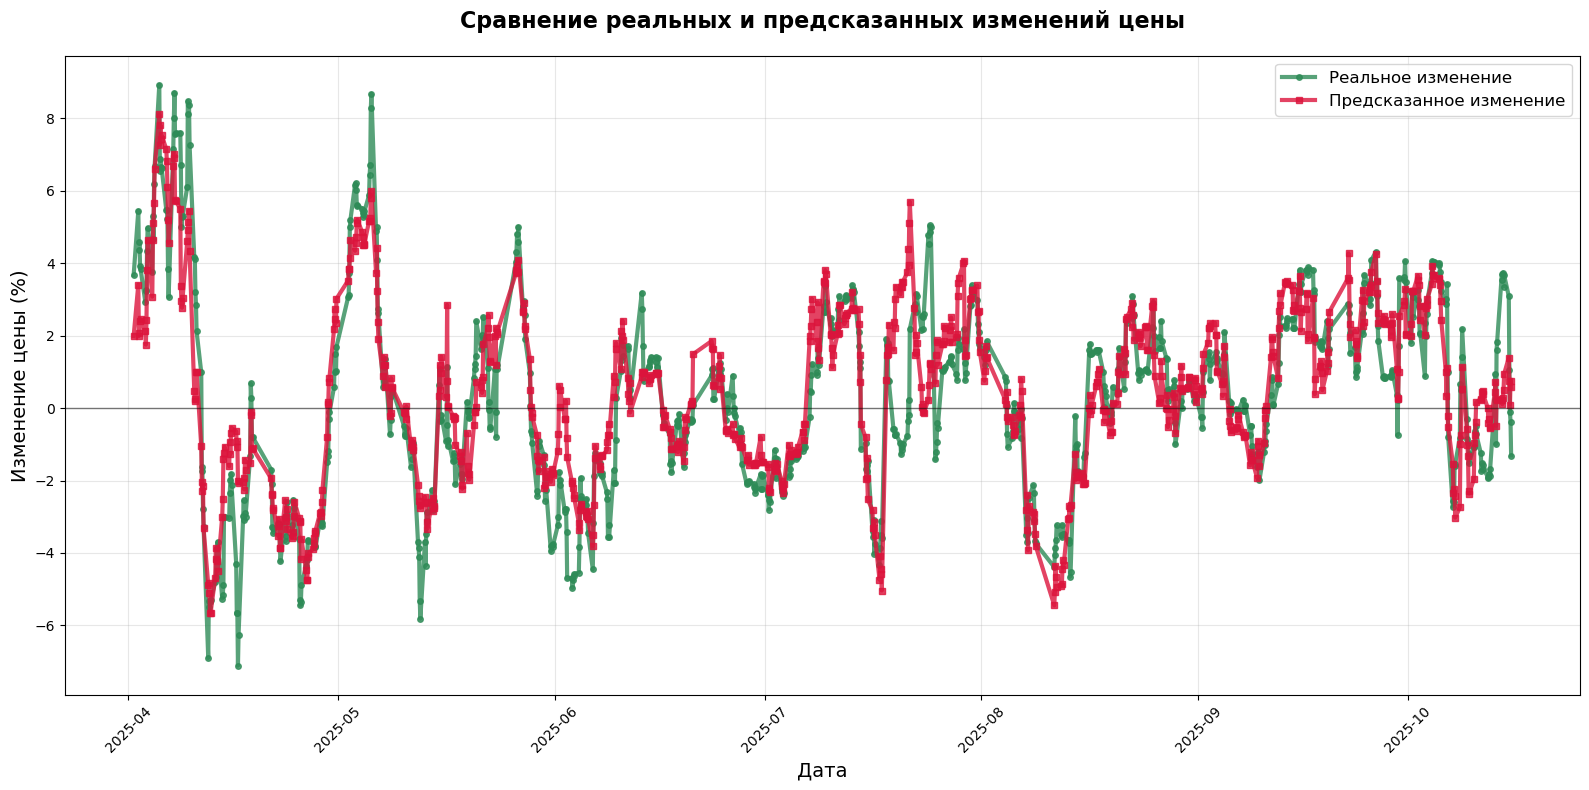

In [149]:
visualize_predictions_comparison(df_SBER_pred)

## 4.2 Газпром

In [155]:
df_GAZP_pred = pd.DataFrame(y_test_GAZP)
df_GAZP_pred = df_GAZP_pred.merge(part_GAZP[['begin', 'close']], left_index=True, right_index=True)
df_GAZP_pred['predict'] = y_pred_GAZP
df_GAZP_pred.head()

,target_price_change,begin,close,predict
3642,17.120344,2025-04-01 18:00:00,139.60,12.213326
3643,19.814963,2025-04-02 10:00:00,137.27,12.092140
3644,18.110067,2025-04-02 12:00:00,139.37,8.340956
3645,17.695621,2025-04-02 14:00:00,139.30,8.328689
3646,17.260788,2025-04-02 16:00:00,138.58,9.042238


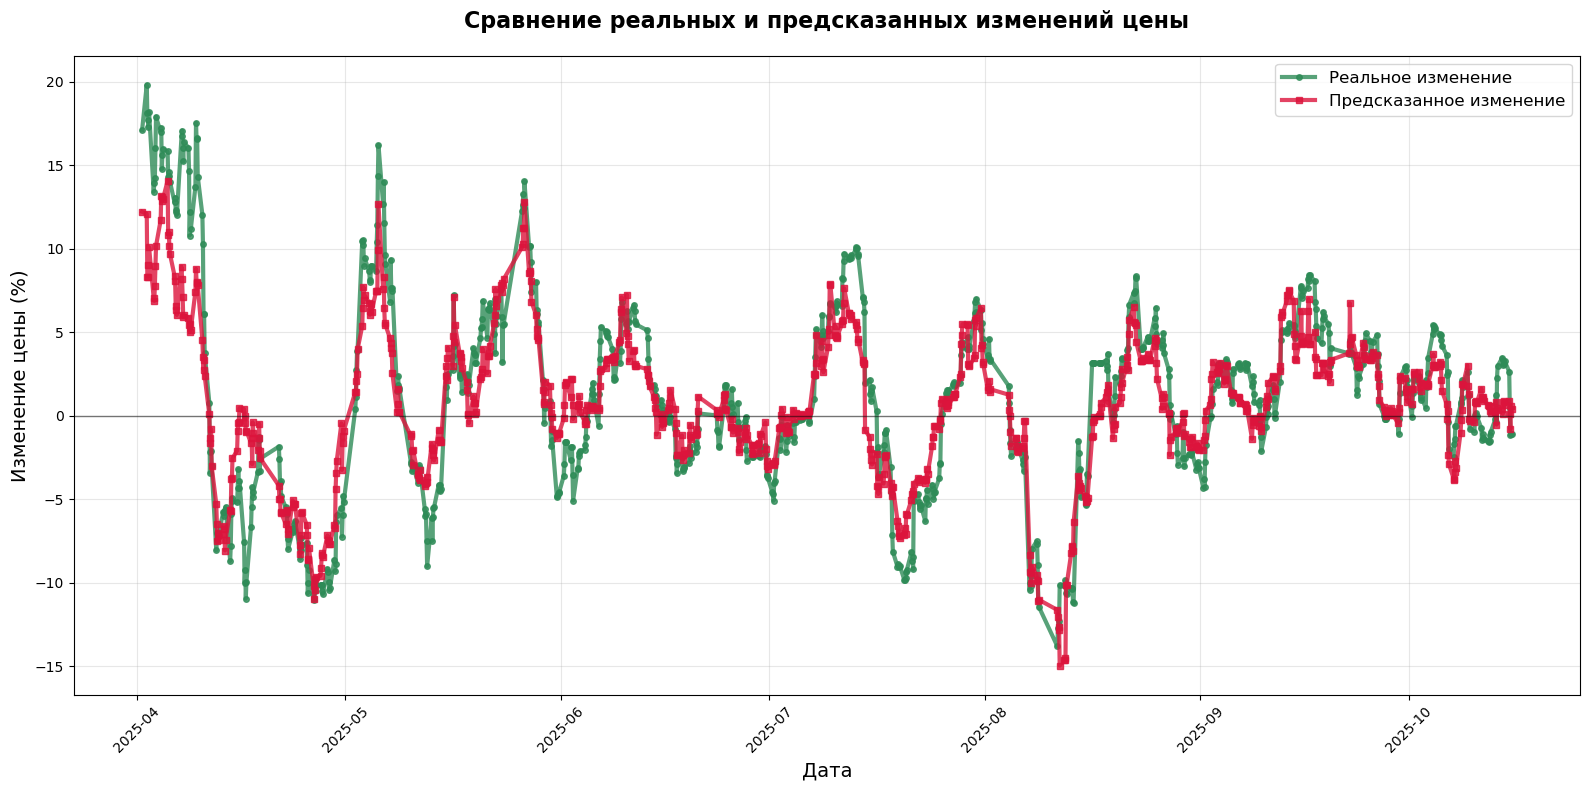

In [157]:
visualize_predictions_comparison(df_GAZP_pred)